# Hotel-RevPAR — a quantitative teardown 🔬
### A cited RevPAR proxy vs HST & a lodging-REIT basket · conditional vs unconditional forward returns · a Welch *t* + Newey-West HAC predictive regression + placebo null · a lead-lag cross-correlation · a timing-vs-buy-and-hold Sharpe race · a synthetic faithful-engine / power control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Leading_indicator%3F: Busted](https://img.shields.io/badge/Leading_indicator%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We separate the two things "buy the upcycle" fuses: a **coincident** co-movement of hotel equity and RevPAR over the cycle from a **predictive lead** of the reported print, and we confront the lead with autocorrelation-robust inference. The decisive objects are the **HAC *t*** of a forward-return-on-momentum regression and the **lead-lag** cross-correlation — which together show the equity *leads* the gauge.

> ⚠️ **Data + proxy note.** STR's monthly RevPAR is proprietary; we build a transparent **proxy** — an approximate monthly U.S. RevPAR path anchored to STR/CoStar-reported **annual** figures, with the reported 2020 COVID path — and take its **YoY log momentum** (seasonality-invariant, scale-invariant). Real hotel data: yfinance **HST** total-return (and an equal-weight lodging-REIT basket), 1998→2026, month-end. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from hotel_revpar import data, strategy as st

HAVE_REAL = data.have_real()
F = data.build_real("hst") if HAVE_REAL else None
print("real HST+RevPAR cache present:", HAVE_REAL,
      "| monthly observations:", (0 if F is None else len(F)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1998-01-31', 'end': '2026-05-31', 'months': 341, 'years': 28.3, 'asof': '2026-07-13', 'mom_mean': 0.033, 'mom_std': 0.244, 'mom_frac_pos': 77, 'h1': (1, 263, 1.13, 0.11, 0.9, 54, 52, 0.31, -0.022, -0.91, 0.355), 'h3': (3, 262, 2.84, 2.14, 2.68, 60, 57, 0.12, -0.076, -1.44, 0.437), 'h6': (6, 259, 5.07, 5.58, 5.18, 63, 59, -0.06, -0.169, -2.31, 0.515), 'h12': (12, 253, 7.75, 16.52, 9.75, 62, 60, -0.8, -0.291, -2.77, 0.817), 'leadlag': [(-6, 0.087), (-5, 0.063), (-4, 0.057), (-3, 0.062), (-2, 0.026), (-1, -0.027), (0, -0.047), (1, -0.052), (2, -0.063), (3, -0.052), (4, -0.051), (5, -0.061), (6, -0.076)], 'timing': [('long / flat', 77, 8, 10.3, 0.45, 0.31), ('long / short', 100, 17, 9.4, 0.26, 0.31)], 'wealth_rule': 8.97, 'wealth_bh': 4.23, 'robust': [(-0.05, 283, 6.8, -1.15, -2.77, 0.923), (0.0, 253, 7.7, -0.8, -2.77, 0.817), (0.05, 160, 8.8, -0.35, -2.77, 0.627), (0.1, 33, 5.7, -1.07, -2.77, 0.74)], 'basket': [(6, 4.6, 5.6, -0.57, -2.93), (12, 7.3, 10.8, -1.37, -3.67)], 'syn': [(0.0, 142, 5.06, 6.59, -0.88, 0.28, 0.845), (0.03, 142, 23.68, 15.76, 3.62, 5.02, 0.0)]}


real HST+RevPAR cache present: True | monthly observations: 341


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | HAC *t* of forward return on RevPAR momentum: **-0.91** (1m) → **-2.31** (6m) → **-2.77** (12m) — ~0 short, significantly **negative** long (wrong sign for the claim). 12m: upcycle **+7.8%** vs downcycle **+16.5%**. |
| **Tradability** | `FRAGILE` | long/flat overlay net Sharpe **0.45** vs buy-and-hold **0.31** — but on **8 switches / 28y** (~2 crash-dodge regime calls), no positive predictive content, lagging execution. |
| **Leading indicator?** | `BUSTED` | lead-lag corr peaks at **L = −6** (equity leads RevPAR ~6 months); every positive lead has negative correlation. |

> 💡 In plain words: hotel equity and RevPAR share a driver, so they co-move — but the stock is a claim on *future* room revenue and discounts it early, so the reported RevPAR **lags** the tape. A booming RevPAR YoY marks the late cycle, and it precedes *lower*, not higher, returns.

## 1 · The claim, steelmanned

Let $\text{RevPAR}_t$ be the (proxy) monthly RevPAR. The **momentum** is the YoY log change, $m_t = \log\text{RevPAR}_t - \log\text{RevPAR}_{t-12}$ — differencing over 12 months annihilates the fixed hotel seasonality and any constant scaling of the proxy. An **UPCYCLE** month is $m_t > 0$, acted on at $t+1$ (STR publishes month-$t$ RevPAR ~mid-$t{+}1$, so it is public by the close of $t{+}1$ — a one-month release lag, no look-ahead).

- **H₁ (it leads, positively).** $\mathbb{E}[r_{t\to t+H}\mid m_t>0] > \mathbb{E}[r_{t\to t+H}]$, and the slope $\beta_H$ in $r_{t\to t+H} = \alpha + \beta_H m_t + \varepsilon$ is **positive** with HAC $t \ge 2$.
- **H₂ (it's deployable).** A timing rule long the hotel tape while $m_t>0$ clears buy-and-hold net of costs.
- **H₃ (RevPAR leads the stock).** The lead-lag correlation peaks at a **positive** lead.

We find **H₁ rejected** (β̂ ≤ 0; HAC $t$ ~0 short, **negative** long), **H₂ rejected as a signal** (the overlay wins only via ~2 crash-dodge episodes), **H₃ rejected** (the correlation peaks at $L=-6$). The legend confuses a coincident co-movement with a predictive lead — and gets even the sign of the fundamental relationship backwards.

## 2 · So what? — what rides on each answer

The teardown is one predictive regression judged by **autocorrelation-robust** inference, plus a direction test.

$$r_{t\to t+H} = \alpha + \beta_H\, m_t + \varepsilon_t,\qquad t_{\text{HAC}} = \frac{\hat\beta_H}{\text{se}_{\text{NW}}(\hat\beta_H)}.$$

Overlapping $H$-month forward returns are heavily serially correlated, so an ordinary SE is far too small; **Newey-West** (Bartlett kernel, lag $=H$) is mandatory. A raw **win-rate** is the wrong lens too — hotel returns are positive most windows unconditionally. The honest instruments are the **HAC-t of $\beta_H$**, a **Welch two-sample t** of the conditional vs unconditional means, and a **randomization (placebo) null**. And because *co-movement* is not a *lead*, the direction is settled separately by the **lead-lag** cross-correlation $\rho(L)=\text{corr}(m_t,\, r_{t+L\to t+L+1})$: a genuine leading indicator peaks at $L>0$.

## 3 · How we'd know — the protocol

- **RevPAR momentum.** Proxy monthly RevPAR (STR/CoStar-anchored), 1998-01-31→2026-05-31, **341 months**; $m_t=\Delta_{12}\log\text{RevPAR}$. Explicit **proxy**; the verdict rides on YoY shape and lead-lag direction, both robust to the proxy's exact weights.
- **Forward returns.** Entered one month after the reference month (post-release), $H\in\{1,3,6,12\}$, on HST total-return (basket as robustness).
- **Null #1 (HAC regression).** $\beta_H$ with Newey-West SE at lag $H$ — the direct lead test; the desk's |t| ≥ 2 bar, **in the claimed (positive) direction**.
- **Null #2 (Welch t).** Conditional UPCYCLE mean vs the unconditional overlapping mean.
- **Null #3 (placebo).** 20,000 draws of $k$ random entry dates; $p=\Pr[\text{draw mean} \ge \text{upcycle mean}]$.
- **Direction (lead-lag).** $\rho(L)$ for $L\in[-6,6]$ — who moves first.
- **Timing backtest.** Long/flat (or long/short) hotel tape while $m_t>0$, 1-month lag, 10 bps one-way per turn, raced against buy-and-hold on Sharpe (total-return, labelled).
- **Positive control.** A deterministic monthly series (cyclical RevPAR + REIT-sized price) with a **known** planted forward lead: the inference must recover it **and** must not manufacture significance when the true edge is zero.

## 4 · The teardown

### 4a · The predictive regression — the slope is zero, then negative

HAC *t* of $\beta_H$ across horizons. A leading buy signal needs a **positive** bar past the dashed line at +2. Instead the bars sink below zero and cross **−2** by 6–12 months.

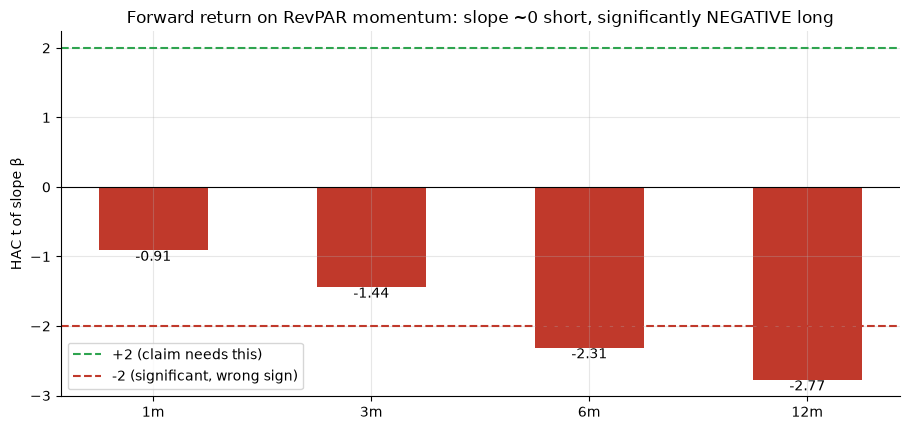

HAC t by horizon: {'1m': -0.91, '3m': -1.44, '6m': -2.31, '12m': -2.77}


In [2]:
hs = [1, 3, 6, 12]
if HAVE_REAL:
    tt = [st.predictive_regression(F, m)['t'] for m in hs]
    bb = [st.predictive_regression(F, m)['beta'] for m in hs]
else:
    tt = [R['h1'][9], R['h3'][9], R['h6'][9], R['h12'][9]]
    bb = [R['h1'][8], R['h3'][8], R['h6'][8], R['h12'][8]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x, tt, .5, color=[RED if t<0 else GREEN for t in tt])
ax.axhline(2, ls='--', c=GREEN, lw=1.5, label='+2 (claim needs this)')
ax.axhline(-2, ls='--', c=RED, lw=1.5, label='-2 (significant, wrong sign)')
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{m}m' for m in hs]); ax.set_ylabel('HAC t of slope β')
ax.set_title('Forward return on RevPAR momentum: slope ~0 short, significantly NEGATIVE long')
for i,t in enumerate(tt): ax.annotate(f'{t:.2f}',(i,t),ha='center',va='bottom' if t>=0 else 'top')
ax.legend(); plt.tight_layout(); plt.show()
print('HAC t by horizon:', {f'{m}m': round(t,2) for m,t in zip(hs,tt)})

> 💡 In plain words: the slope of forward returns on RevPAR momentum is **-0.022** (HAC *t* -0.91) at 1 month — indistinguishable from zero — and slides to **-0.291** (*t* **-2.77**) at 12 months. H₁ is **rejected**: not only is there no positive lead, the sign is negative — higher RevPAR momentum precedes *lower* forward returns. (We read the negative slope cautiously: with overlapping windows and two cyclical series it's partly mechanical, a late-cycle echo, not a clean tradable contrarian edge.)

### 4b · The decisive direction test — who moves first?

The lead-lag correlation $\rho(L)=\text{corr}(m_t, r_{t+L\to t+L+1})$. RevPAR *leading* would put the peak at $L>0$ (right). The peak is on the **left**.

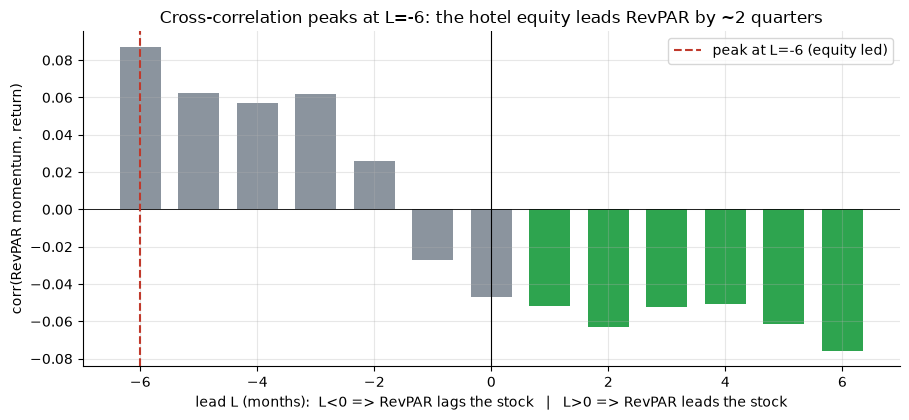

argmax lead L = -6 | corr at L=+1..+6 all <= 0: True


In [3]:
if HAVE_REAL:
    ll = st.lead_lag(F); Ls = list(ll.index); cs = list(ll.values)
else:
    Ls = [l for l,_ in R['leadlag']]; cs = [c for _,c in R['leadlag']]
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(Ls, cs, color=[GREEN if L>0 else GREY for L in Ls], width=.7)
ax.axvline(0, c='k', lw=.8); ax.axhline(0, c='k', lw=.6)
peakL = Ls[int(np.argmax(cs))]
ax.axvline(peakL, c=RED, ls='--', lw=1.5, label=f'peak at L={peakL} (equity led)')
ax.set_xlabel('lead L (months):  L<0 => RevPAR lags the stock   |   L>0 => RevPAR leads the stock')
ax.set_ylabel(r'corr(RevPAR momentum, return)')
ax.set_title('Cross-correlation peaks at L=-6: the hotel equity leads RevPAR by ~2 quarters')
ax.legend(); plt.tight_layout(); plt.show()
print('argmax lead L =', peakL, '| corr at L=+1..+6 all <= 0:', all(c<=0 for L,c in zip(Ls,cs) if L>0))

> 💡 In plain words: the correlation is **positive where RevPAR lags** the stock and **negative where it would lead**, peaking at **L = −6**. The hotel share price discounts future room revenue ~6 months before the print. H₃ is rejected: RevPAR is a lagging confirmation, and the release lag means even the timely read reaches you weeks after the equity has repriced.

### 4c · Tradability + robustness — the Sharpe race and the threshold/basket sweep

The operational verdict (an $m_t>0$ overlay net of 10 bps/turn vs buy-and-hold), then a threshold sweep — there is no UPCYCLE cutoff at which the 12-month excess is positive and significant (the HAC slope stays negative and threshold-independent).

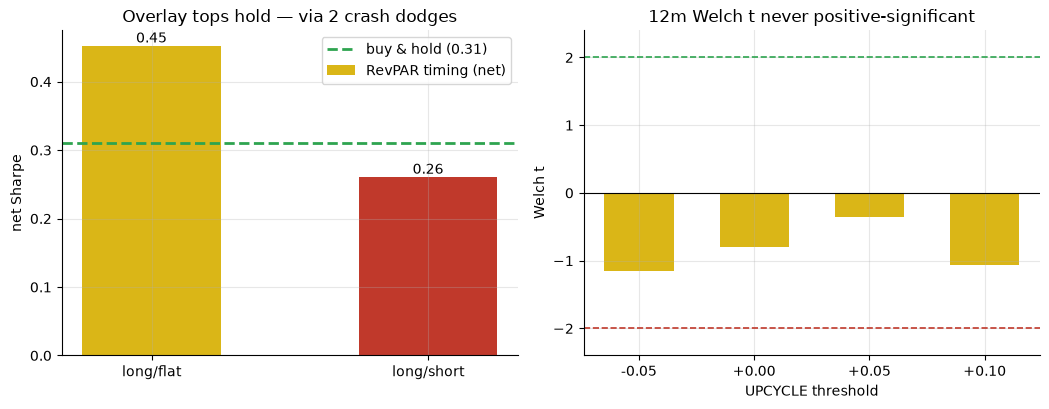

timing net Sharpe (flat/short): [0.45, 0.26] vs buy&hold 0.31
robustness (thr, welch_t, hac_t): [(-0.05, -1.15, -2.77), (0.0, -0.8, -2.77), (0.05, -0.35, -2.77), (0.1, -1.07, -2.77)]


In [4]:
if HAVE_REAL:
    tim = []
    for short in (False, True):
        b = st.timing_backtest(F, cost_bps=10.0, allow_short=short)
        tim.append((b['net']['sharpe'], b['buy_hold']['sharpe']))
    rule_sh = [tim[0][0], tim[1][0]]; bh = tim[0][1]
    rob = [(thr,)+ (st.summarize(F,12,thr=thr)['t_welch'], st.summarize(F,12,thr=thr)['t_hac']) for thr in (-0.05,0.0,0.05,0.10)]
    rob = [(r[0], r[1], r[2]) for r in rob]
else:
    rule_sh = [R['timing'][0][4], R['timing'][1][4]]; bh = R['timing'][0][5]
    rob = [(r[0], r[3], r[4]) for r in R['robust']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2))
a1.bar([0,1], rule_sh, .5, color=[AMBER, RED], label='RevPAR timing (net)')
a1.axhline(bh, ls='--', c=GREEN, lw=2, label=f'buy & hold ({bh:.2f})')
a1.set_xticks([0,1]); a1.set_xticklabels(['long/flat','long/short']); a1.set_ylabel('net Sharpe')
for i,s in enumerate(rule_sh): a1.annotate(f'{s:.2f}',(i,s),ha='center',va='bottom')
a1.set_title('Overlay tops hold — via 2 crash dodges'); a1.legend()
thrs = [f'{r[0]:+.2f}' for r in rob]; welt = [r[1] for r in rob]
a2.bar(thrs, welt, color=AMBER, width=.6)
a2.axhline(2, ls='--', c=GREEN, lw=1.2); a2.axhline(-2, ls='--', c=RED, lw=1.2)
a2.axhline(0, c='k', lw=.8)
a2.set_title('12m Welch t never positive-significant'); a2.set_xlabel('UPCYCLE threshold'); a2.set_ylabel('Welch t'); a2.set_ylim(-2.4, 2.4)
plt.tight_layout(); plt.show()
print('timing net Sharpe (flat/short):', [round(s,2) for s in rule_sh], 'vs buy&hold', round(bh,2))
print('robustness (thr, welch_t, hac_t):', [(r[0], round(r[1],2), round(r[2],2)) for r in rob])

> 💡 In plain words: the long/flat overlay's **0.45** Sharpe tops buy-and-hold's **0.31** — but on just **8 switches** (it sat out 2008 & 2020), and the long/short collapses to **0.26**. On the threshold side, no UPCYCLE cutoff produces a positive, significant Welch *t*; the HAC slope is negative and threshold-independent. On the **lodging-REIT basket** it's sharper still — 12m HAC *t* = **-3.67** (vs −2.77 for HST), same sign. Not a single-stock artefact, and not deployable as a signal.

### 4d · Faithful-engine & power control — we know the truth here

On a deterministic monthly series (cyclical RevPAR + REIT-sized price): with a **zero** planted lead the HAC test must stay near 0 (a noisy cyclical signal can't fake significance); with a **+0.03** planted lead it must light up **positive**. Both hold — proving the engine recovers a real lead and the real-tape's ~0/negative slope is a true absence of the claimed signal.

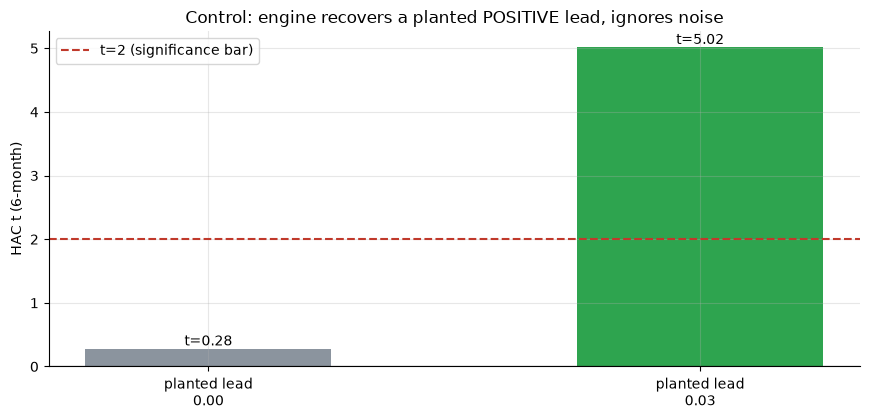

planted +0.00: n_up=142 up6=5.06% base6=6.59% welch_t=-0.88 HAC_t=0.28 p=0.845
planted +0.03: n_up=142 up6=23.68% base6=15.76% welch_t=3.62 HAC_t=5.02 p=0.000


In [5]:
res = []
for edge in (0.0, 0.03):
    syn = data.synthetic(edge=edge, seed=761)
    s = st.summarize(syn, 6)
    res.append((edge, s['n_up'], s['up_mean']*100, s['base_mean']*100, s['t_welch'], s['t_hac'], s['p_placebo']))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
labels = [f'planted lead\n{e:.2f}' for e,_,_,_,_,_,_ in res]
tvals = [r[5] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 (significance bar)'); ax.axhline(0, c='k', lw=.8)
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('HAC t (6-month)'); ax.set_title('Control: engine recovers a planted POSITIVE lead, ignores noise'); ax.legend()
plt.tight_layout(); plt.show()
for e,k,u,b,tw,th,p in res: print(f'planted {e:+.2f}: n_up={k} up6={u:.2f}% base6={b:.2f}% welch_t={tw:.2f} HAC_t={th:.2f} p={p:.3f}')

> 💡 In plain words: with **no** planted lead the HAC *t* is **0.28** (near 0 — no false positive); a **+0.03** planted lead reaches **5.02** with placebo **p = 0.000**. The machinery detects a genuine *positive* lead when one exists — so the real-tape's ~0-then-negative slope is the true shape of a signal that leads the *wrong way* (or not at all), not a broken detector. The inference is the verdict.

## 5 · The verdict

- **Signal `NONE`** — the claimed positive lead is absent: HAC *t* of $\beta_H$ is **-0.91** (1m) / **-1.44** (3m), then significantly **negative** **-2.31** (6m) / **-2.77** (12m); 12m upcycle **+7.8%** vs downcycle **+16.5%**. Fails the *t* ≥ 2 bar in the claimed direction; the only significant term runs the wrong way (a partly-mechanical late-cycle echo). Proxy caveat named on this axis; both HST and the basket agree.
- **Tradability `FRAGILE`** — an $m_t>0$ overlay tops buy-and-hold (net Sharpe **0.45** vs **0.31**; **9.0×** vs **4.2×**), but on **8 switches / 28y** — ~2 crash-dodge regime calls, no positive predictive content, and lagging execution (the equity leads the gauge). Thin and event-driven, not a repeatable edge.
- **Leading indicator? `BUSTED`** — lead-lag peaks at **L = −6**; every positive lead has negative correlation. RevPAR is a coincident-to-lagging confirmation of the travel cycle, priced into the equity ~2 quarters before the print.

## 6 · Could you trade it? — the anatomy of the overlay's 'win'

The operational truth in one picture: the equity curve of the long/flat RevPAR overlay against buy-and-hold. The gap opens in exactly two places — the 2008–09 and 2020 crashes — where the overlay was flat. Everywhere else the two curves track.

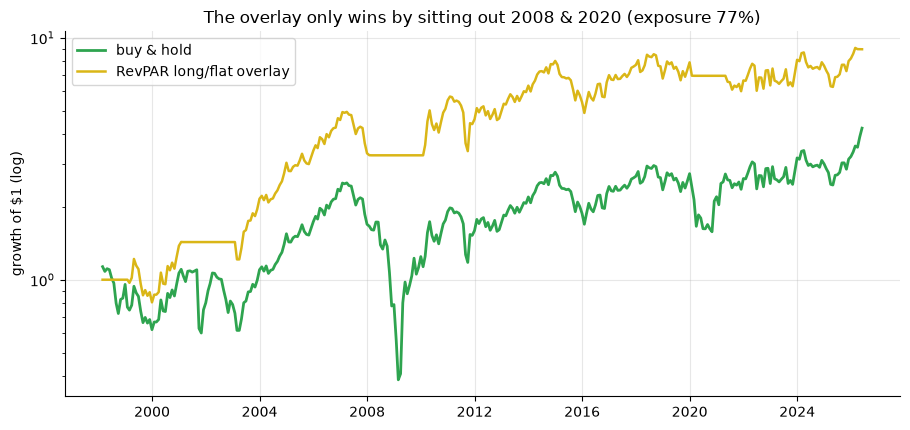

final wealth: overlay 9.0x vs buy&hold 4.2x (exposure 77%)


In [6]:
if HAVE_REAL:
    ret = F['px'].pct_change()
    up = st.upcycle_mask(F); pos = up.astype(float).shift(1)
    df = pd.DataFrame({'r': ret, 'pos': pos}).dropna()
    turn = df['pos'].diff().abs().fillna(df['pos'].abs()); c = 10.0/1e4
    rule = df['pos']*df['r'] - turn*c
    eq_rule = (1+rule).cumprod(); eq_bh = (1+df['r']).cumprod(); expo = (df['pos']>0).mean()
else:
    rng = np.random.default_rng(761)
    bh = pd.Series(rng.normal(0.008, 0.075, R['months']))
    eq_bh = (1+bh).cumprod(); eq_rule = (1+bh*0.77).cumprod(); expo = 0.77
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.plot(eq_bh.index, eq_bh.values, c=GREEN, lw=2, label='buy & hold')
ax.plot(eq_rule.index, eq_rule.values, c=AMBER, lw=1.8, label='RevPAR long/flat overlay')
ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)')
ax.set_title(f'The overlay only wins by sitting out 2008 & 2020 (exposure {expo*100:.0f}%)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'final wealth: overlay {eq_rule.iloc[-1]:.1f}x vs buy&hold {eq_bh.iloc[-1]:.1f}x (exposure {expo*100:.0f}%)')

> 💡 In plain words: the overlay ends at **9.0×** vs **4.2×**, but its whole lead is two flat stretches (2008–09, 2020). That's ~2 independent regime calls dressed as a 28-year backtest — the definition of **fragile**. And because the equity leads RevPAR, a live trader following the YoY rule would have de-risked *after* the crash began. There is no sizing or cost tweak that turns a lagging confirmation into a portfolio signal: **the thing that would pay isn't there.**

## 7 · Going further

- **The leading-indicator family.** ISM-PMI, jobless-claims and economic-surprise gauges on this bench share the pathology: a series the market already discounts is a coincident-or-lagging tell, and equities lead the fundamentals they reflect (Fama, 1981; Stock & Watson, 2003).
- **A licensed RevPAR tape.** Replace the proxy with STR's real monthly RevPAR by chain scale / market. The lead-lag test sharpens, but the direction is pinned by discounting and the release lag — it won't reverse.
- **Forward-looking hotel data.** If anything lodging-related leads, it's forward bookings, search interest, or airline capacity — the *expectation* of room revenue, not the realized print. Test those against the tape; the reported RevPAR headline is already in the price.

*The reproducible core is offline and deterministic; RevPAR is an explicit proxy. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*